In [1]:
import os
import glob
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.dpi'] = 100

INPUT_FOLDER = "local_dataset"
OUTDOOR_FILE = "outdoorweather.csv"
PROCESSED_FOLDER = "local_processed_data"
EDA_FILE = "eda_aligned_data.csv"

if not os.path.exists(PROCESSED_FOLDER):
    os.makedirs(PROCESSED_FOLDER)

In [2]:
# Load the outdoor weather data, backfill missing values
# and create a historical average profile to fill in large gaps
#
outdoor_path = os.path.join(INPUT_FOLDER, OUTDOOR_FILE)
outdoor_df = pd.read_csv(outdoor_path, sep=';')
outdoor_df["Timestamp"] = pd.to_datetime(outdoor_df["Timestamp"])
outdoor_df = outdoor_df.sort_values("Timestamp").drop_duplicates(subset=["Timestamp"])
outdoor_df = outdoor_df.rename(columns={"Temperature": "Outdoor_Temperature"})

outdoor_df["outsideMinTemp"] = outdoor_df["outsideMinTemp"].fillna(outdoor_df["Outdoor_Temperature"]).bfill()
outdoor_df["outsideMaxTemp"] = outdoor_df["outsideMaxTemp"].fillna(outdoor_df["Outdoor_Temperature"]).bfill()
outdoor_df["outsideHumidity"] = outdoor_df["outsideHumidity"].bfill()

outdoor_df["Month"] = outdoor_df["Timestamp"].dt.month
outdoor_df["Hour"] = outdoor_df["Timestamp"].dt.hour
fallback_profile = outdoor_df.groupby(["Month", "Hour"])[["Outdoor_Temperature", "outsideMinTemp", "outsideMaxTemp", "outsideHumidity"]].mean().reset_index()
outdoor_df = outdoor_df.drop(columns=["Month", "Hour"])

In [3]:
# This loop processes each individual indoor thermostat CSV file by applying
# forward fills to carry state data through sparse logging events.
# The script then aligns these logs with the outdoor weather data using
# 1-minute time based interpolation for temperature and forward fills
# for the environmental envelopes.
# It performs feature engineering by transforming months, days, and hours
# into cyclical sine and cosine coordinates to represent continuous time.
# the program removes raw timestamps and years to prevent data leakage 
#--------------------------------------------------------------------------------

# collect all csv files from the input directory
#
all_csvs = glob.glob(os.path.join(INPUT_FOLDER, "*.csv"))

# filter list to identify files containing indoor thermostat data
#
indoor_csvs = [f for f in all_csvs if os.path.basename(f) != OUTDOOR_FILE]

# check for existing eda file and remove it to prevent appending to old data
#
if os.path.exists(EDA_FILE):
    os.remove(EDA_FILE)

# iterate through the list of identified indoor data files
#
for i, csv_path in enumerate(indoor_csvs):

    # load the raw indoor thermostat data into a dataframe
    #
    df = pd.read_csv(csv_path, sep=',')

    # standardize column names for consistent downstream processing
    #
    df = df.rename(columns={
        "output_state": "OutputState", "fan_state": "FanState",
        "running_mode": "RunningMode", "temp": "Temperature", "set_point": "Setpoint"
    })

    # convert the timestamp strings into datetime objects
    #
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])

    # sort data by time and apply forward fills to maintain state values
    #
    df = df.sort_values("Timestamp").reset_index(drop=True).ffill()
    
    # define the time range for current file with a one hour buffer
    #
    min_ts, max_ts = df["Timestamp"].min() - pd.Timedelta(hours=1), df["Timestamp"].max() + pd.Timedelta(hours=1)

    # slice the global outdoor weather data to match the local time window
    #
    local_out = outdoor_df[(outdoor_df["Timestamp"] >= min_ts) & (outdoor_df["Timestamp"] <= max_ts)].copy()
    
    # check if the local outdoor subset contains any valid data points
    #
    if not local_out.empty:

        # set timestamp as index to prepare for resampling and interpolation
        #
        local_out = local_out.set_index("Timestamp")

        # resample temperature to one minute and apply time based interpolation
        #
        out_temp = local_out[["Outdoor_Temperature"]].resample("1min").mean().interpolate(method="time").astype("float32")

        # resample environmental values and apply forward fills for the envelope
        #
        out_env = local_out[["outsideMinTemp", "outsideMaxTemp", "outsideHumidity"]].resample("1min").ffill().astype("float32")

        # combine the interpolated temperature and environmental envelope data
        #
        out_res = pd.concat([out_temp, out_env], axis=1)

    # create an empty weather dataframe if no local outdoor data exists
    #
    else:
        out_res = pd.DataFrame(columns=["Outdoor_Temperature", "outsideMinTemp", "outsideMaxTemp", "outsideHumidity"])

    # create a temporary column with timestamps rounded to the nearest minute
    #
    df["Timestamp_min"] = df["Timestamp"].dt.round("1min")

    # perform a left join to align outdoor weather with indoor timestamps
    #
    merged = pd.merge(df, out_res, left_on="Timestamp_min", right_index=True, how="left").drop(columns=["Timestamp_min"])

    # check joined data for missing outdoor values to trigger fallback logic
    #
    if merged["Outdoor_Temperature"].isna().any():

        # extract time components to map against the historical weather profile
        #
        merged["Month"], merged["Hour"] = merged["Timestamp"].dt.month, merged["Timestamp"].dt.hour

        # join with the historical fallback profile to fill missing weather gaps
        #
        merged = pd.merge(merged, fallback_profile, on=["Month", "Hour"], how="left", suffixes=("", "_fallback"))

        # fill each missing environmental column with historical average values
        #
        for col in ["Outdoor_Temperature", "outsideMinTemp", "outsideMaxTemp", "outsideHumidity"]:
            merged[col] = merged[col].fillna(merged[f"{col}_fallback"]).ffill().bfill() 
            merged = merged.drop(columns=[f"{col}_fallback"])

        # drop the temporary time component columns used for the fallback join
        #
        merged = merged.drop(columns=["Month", "Hour"])

    # calculate the sine component for the cyclical hour feature
    #
    merged["Hour_Sin"] = np.sin(2 * np.pi * merged["Timestamp"].dt.hour / 24.0).astype("float32")

    # calculate the cosine component for the cyclical hour feature
    #
    merged["Hour_Cos"] = np.cos(2 * np.pi * merged["Timestamp"].dt.hour / 24.0).astype("float32")

    # calculate the sine component for the cyclical day of year feature
    #
    merged["Day_Sin"] = np.sin(2 * np.pi * merged["Timestamp"].dt.dayofyear / 365.25).astype("float32")

    # calculate the cosine component for the cyclical day of year feature
    #
    merged["Day_Cos"] = np.cos(2 * np.pi * merged["Timestamp"].dt.dayofyear / 365.25).astype("float32")

    # calculate the sine component for the cyclical month feature
    #
    merged["Month_Sin"] = np.sin(2 * np.pi * merged["Timestamp"].dt.month / 12.0).astype("float32")

    # calculate the cosine component for the cyclical month feature
    #
    merged["Month_Cos"] = np.cos(2 * np.pi * merged["Timestamp"].dt.month / 12.0).astype("float32")
    
    # record the name of the source file for analysis tracking
    #
    merged["source_file"] = os.path.basename(csv_path)

    # append the current processed data chunk to the master eda file
    #
    merged.to_csv(EDA_FILE, mode='a', header=(i==0), index=False)
    
    # drop timestamp and source information to prepare for model training
    #
    ml_ready_df = merged.drop(columns=["Timestamp", "source_file"])

    # define the output path for the individual processed machine learning file
    #
    ml_filename = os.path.join(PROCESSED_FOLDER, f"processed_{os.path.basename(csv_path)}")

    # save the clean numeric data to the local processed data directory
    #
    ml_ready_df.to_csv(ml_filename, index=False)
    
    # remove large dataframes from memory to prevent system crashes
    #
    del df, merged, local_out, out_res, ml_ready_df

    # trigger garbage collection to reclaim memory resources
    #
    gc.collect()

# delete the global outdoor weather dataframe from memory
#
del outdoor_df

# perform a final garbage collection pass to clean up all resources
#
gc.collect()

0

In [4]:
# Display basic summary statistics for the numerical variables
#
sample_stats = pd.read_csv(EDA_FILE, nrows=500000).dropna()
display(sample_stats.drop(columns=["Timestamp", "source_file"]).describe().round(2))
del sample_stats
gc.collect()

,Temperature,Setpoint,FanState,OutputState,RunningMode,Outdoor_Temperature,outsideMinTemp,outsideMaxTemp,outsideHumidity,Hour_Sin,Hour_Cos,Day_Sin,Day_Cos,Month_Sin,Month_Cos
count,320994.00,320994.00,320994.00,320994.00,320994.00,320994.00,320994.00,320994.00,320994.00,320994.00,320994.00,320994.00,320994.00,320994.00,320994.00
mean,21.35,21.52,0.47,0.48,0.47,9.41,8.50,10.19,69.78,-0.00,-0.02,-0.30,0.52,-0.14,0.57
std,1.86,1.43,0.50,0.50,0.50,11.53,11.46,11.60,17.65,0.70,0.71,0.54,0.59,0.63,0.51
min,10.05,17.22,0.00,0.00,0.00,-14.20,-15.08,-13.86,16.00,-1.00,-1.00,-1.00,-0.99,-1.00,-0.87
25%,20.59,20.56,0.00,0.00,0.00,0.88,0.21,1.78,58.00,-0.71,-0.71,-0.78,0.12,-0.87,0.50
50%,21.53,21.11,0.00,0.00,0.00,6.07,5.21,6.90,72.59,0.00,-0.00,-0.42,0.84,-0.00,0.87
75%,22.49,22.22,1.00,1.00,1.00,19.17,18.10,20.14,84.00,0.71,0.71,0.24,0.93,0.50,1.00
max,28.10,25.00,1.00,1.00,1.00,37.10,35.70,38.10,100.00,1.00,1.00,0.72,1.00,0.87,1.00


0

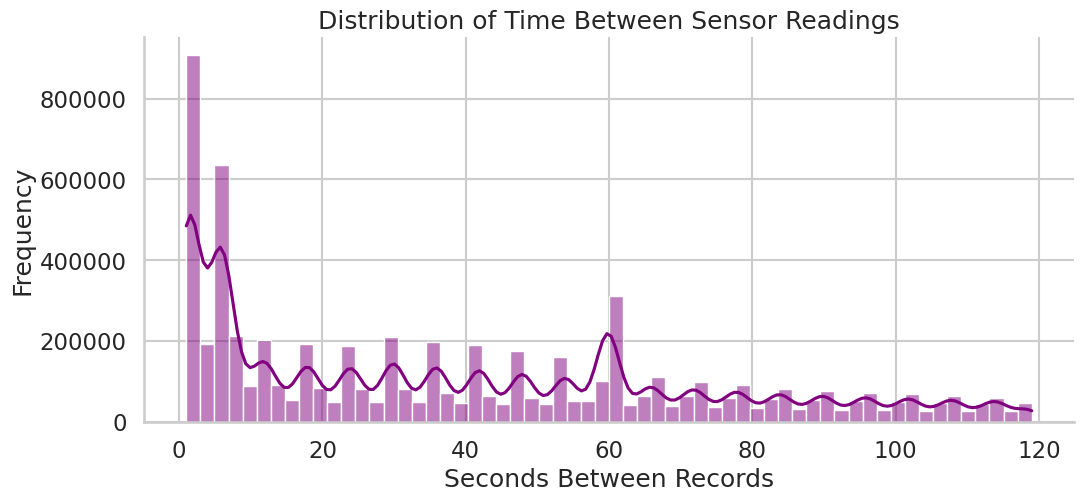

103

In [5]:
# Visualize the reliability of the sensors by plotting a distribution 
# of the time delays between each recorded data point.
#
chunk_iter = pd.read_csv(EDA_FILE, usecols=["source_file", "Timestamp"], chunksize=100000)
gap_data = []

for chunk in chunk_iter:
    chunk["Timestamp"] = pd.to_datetime(chunk["Timestamp"])
    chunk = chunk.sort_values(["source_file", "Timestamp"])
    chunk["TimeGap_Seconds"] = chunk.groupby("source_file")["Timestamp"].diff().dt.total_seconds()
    gap_data.append(chunk["TimeGap_Seconds"].dropna())

all_gaps = pd.concat(gap_data)

fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(all_gaps[(all_gaps < 120) & (all_gaps > 0)], bins=60, kde=True, color="purple", ax=ax)
ax.set_title("Distribution of Time Between Sensor Readings")
ax.set_xlabel("Seconds Between Records")
ax.set_ylabel("Frequency")
sns.despine()
plt.show()

del all_gaps, gap_data, chunk_iter
gc.collect()

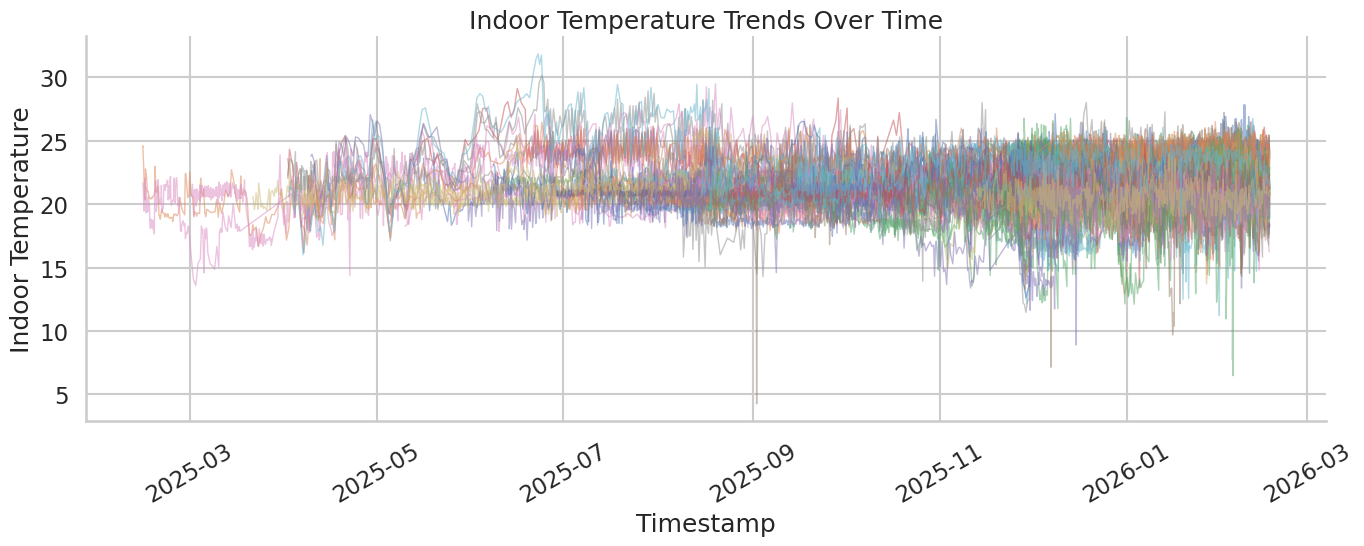

6089

In [6]:
# Plot a zoomed out macro timeline of the indoor temperatures
# to identify broad seasonal trends or massive outages
#
macro_chunks = []
for chunk in pd.read_csv(EDA_FILE, usecols=["Timestamp", "Temperature", "source_file"], chunksize=100000):
    chunk["Timestamp"] = pd.to_datetime(chunk["Timestamp"])
    macro_chunks.append(chunk.iloc[::120]) 

macro_df = pd.concat(macro_chunks).dropna()

fig, ax = plt.subplots(figsize=(16, 5))
for src, grp in macro_df.groupby("source_file"):
    ax.plot(grp["Timestamp"], grp["Temperature"], linewidth=1, alpha=0.5)

ax.set_title("Indoor Temperature Trends Over Time")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Indoor Temperature")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=30)
sns.despine()
plt.show()

del macro_df, macro_chunks
gc.collect()

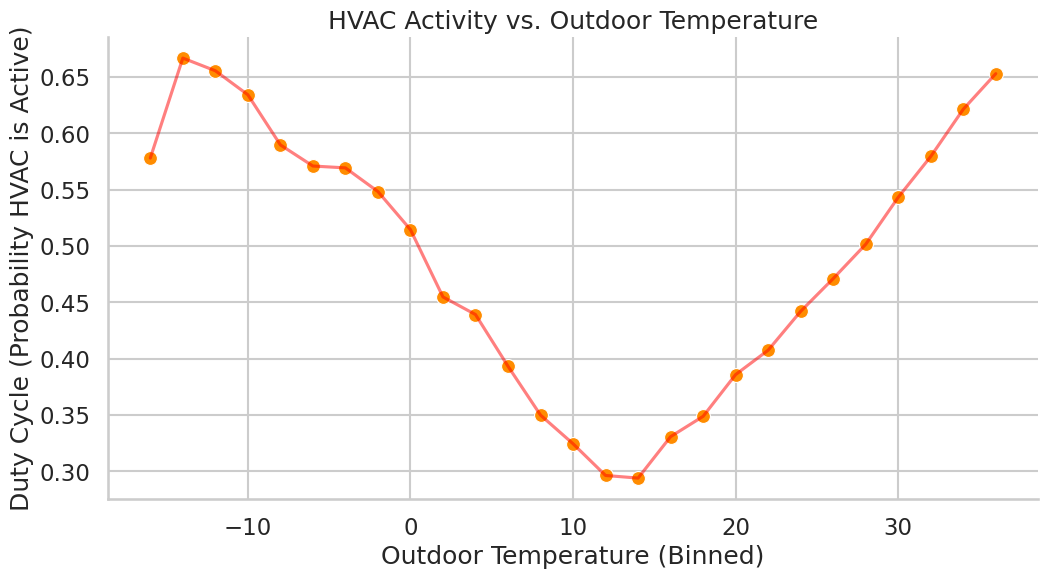

9404

In [7]:
# Calculate and plot the system's duty cycle (the percentage of time the HVAC is running)
# against the outdoor temperature to see at what temperature the system works hardest
#
header = pd.read_csv(EDA_FILE, nrows=0).columns
state_col = "OutputState" if "OutputState" in header else "RunningMode"

duty_chunks = []
for chunk in pd.read_csv(EDA_FILE, usecols=["Outdoor_Temperature", state_col], chunksize=100000):
    duty_chunks.append(chunk.dropna())

duty_df = pd.concat(duty_chunks)
duty_df["Outdoor_Bin"] = (duty_df["Outdoor_Temperature"] // 2) * 2
duty_cycle = duty_df.groupby("Outdoor_Bin")[state_col].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(data=duty_cycle, x="Outdoor_Bin", y=state_col, color="darkorange", s=100, ax=ax)
sns.lineplot(data=duty_cycle, x="Outdoor_Bin", y=state_col, color="red", alpha=0.5, ax=ax)

ax.set_title("HVAC Activity vs. Outdoor Temperature")
ax.set_xlabel("Outdoor Temperature (Binned)")
ax.set_ylabel("Duty Cycle (Probability HVAC is Active)")
sns.despine()
plt.show()

del duty_df, duty_cycle
gc.collect()

/tmp/ipykernel_6685/1271519197.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=delta_duty, x="Delta_T_Bin", y=state_col, palette="viridis", ax=ax)


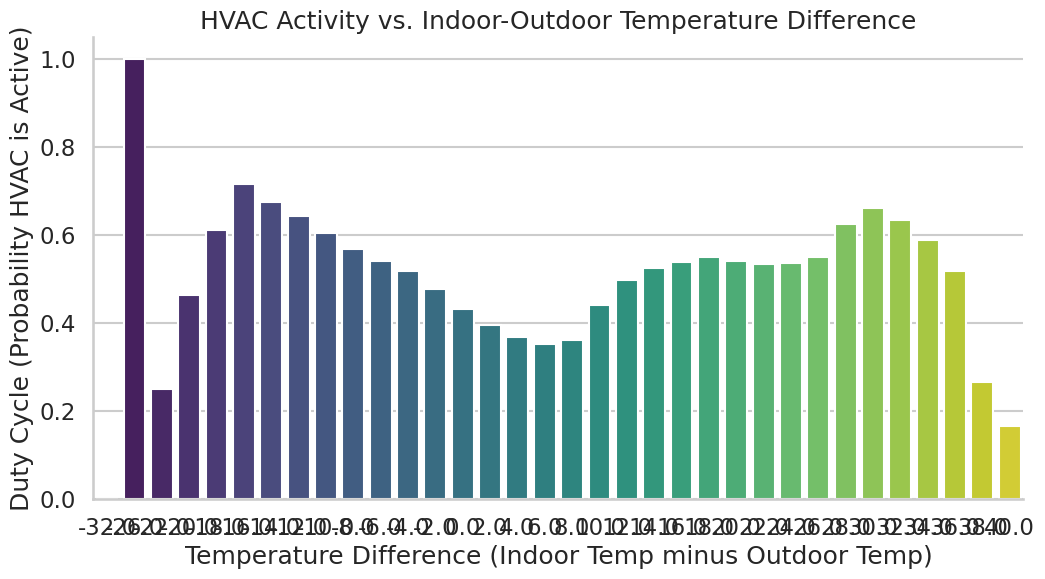

3488

In [8]:
# Plot the duty cycle against the difference between indoor and outdoor
# temperatures to see how hard the system works 
#
delta_chunks = []
for chunk in pd.read_csv(EDA_FILE, usecols=["Temperature", "Outdoor_Temperature", state_col], chunksize=100000):
    valid = chunk.dropna().copy()
    valid["Delta_T"] = valid["Temperature"] - valid["Outdoor_Temperature"]
    delta_chunks.append(valid)

delta_df = pd.concat(delta_chunks)
delta_df["Delta_T_Bin"] = (delta_df["Delta_T"] // 2) * 2
delta_duty = delta_df.groupby("Delta_T_Bin")[state_col].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=delta_duty, x="Delta_T_Bin", y=state_col, palette="viridis", ax=ax)

ax.set_title("HVAC Activity vs. Indoor-Outdoor Temperature Difference")
ax.set_xlabel("Temperature Difference (Indoor Temp minus Outdoor Temp)")
ax.set_ylabel("Duty Cycle (Probability HVAC is Active)")
sns.despine()
plt.show()

del delta_df, delta_duty, delta_chunks
gc.collect()

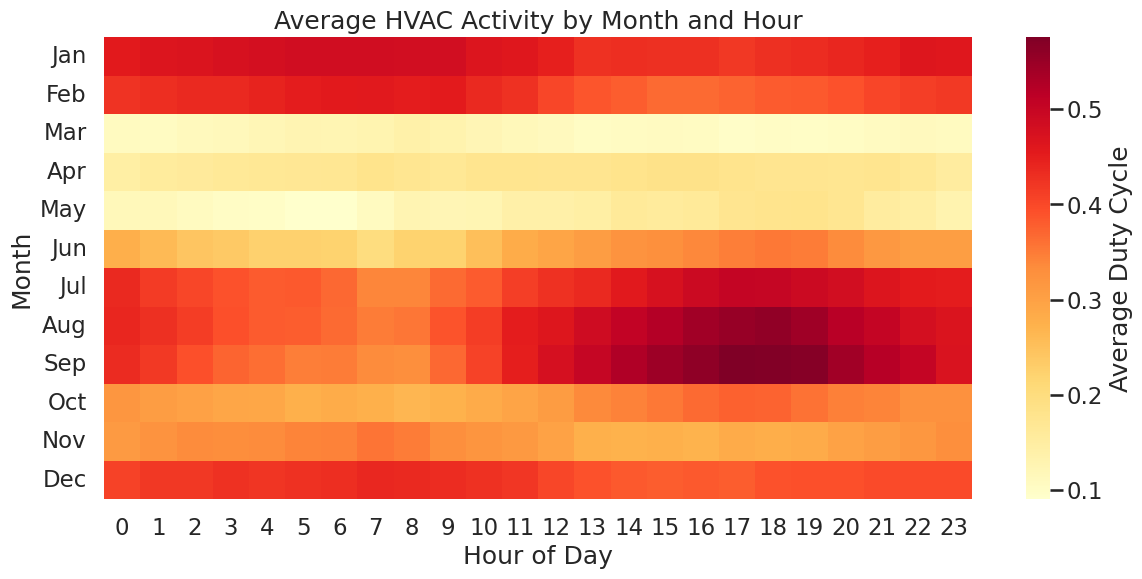

9603

In [9]:
# Create a heatmap showing the average HVAC activity broken down by the month 
# of the year and the hour of the day
#
heat_chunks = []
for chunk in pd.read_csv(EDA_FILE, usecols=["Timestamp", state_col], chunksize=100000):
    chunk["Timestamp"] = pd.to_datetime(chunk["Timestamp"])
    chunk["Month"] = chunk["Timestamp"].dt.month
    chunk["Hour"] = chunk["Timestamp"].dt.hour
    heat_chunks.append(chunk.groupby(["Month", "Hour"])[state_col].mean().reset_index())

heat_df = pd.concat(heat_chunks)
heat_summary = heat_df.groupby(["Month", "Hour"])[state_col].mean().unstack()
heat_summary.index = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"][:len(heat_summary.index)]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heat_summary, cmap="YlOrRd", ax=ax, cbar_kws={'label': 'Average Duty Cycle'})
ax.set_title("Average HVAC Activity by Month and Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Month")
plt.show()

del heat_chunks, heat_df, heat_summary
gc.collect()

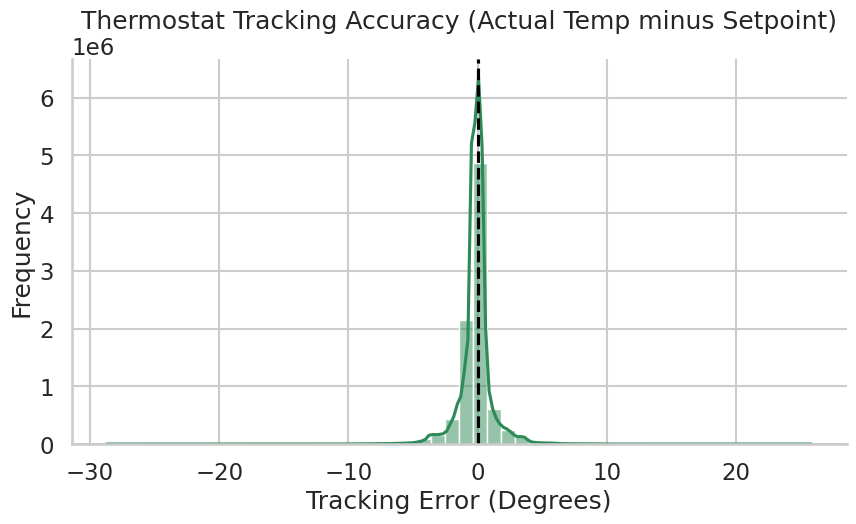

7317

In [10]:
# Analyze the accuracy of the climate control system by plotting the distribution of the 
# difference between the actual indoor temperature and the target setpoint
#
track_chunks = []
for chunk in pd.read_csv(EDA_FILE, usecols=["Temperature", "Setpoint"], chunksize=100000):
    valid = chunk.dropna().copy()
    valid["Tracking_Error"] = valid["Temperature"] - valid["Setpoint"]
    track_chunks.append(valid)

track_df = pd.concat(track_chunks)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(track_df["Tracking_Error"], bins=50, kde=True, color="seagreen", ax=ax)
ax.set_title("Thermostat Tracking Accuracy (Actual Temp minus Setpoint)")
ax.set_xlabel("Tracking Error (Degrees)")
ax.set_ylabel("Frequency")
ax.axvline(0, color="black", linestyle="--")
sns.despine()
plt.show()

del track_df, track_chunks
gc.collect()

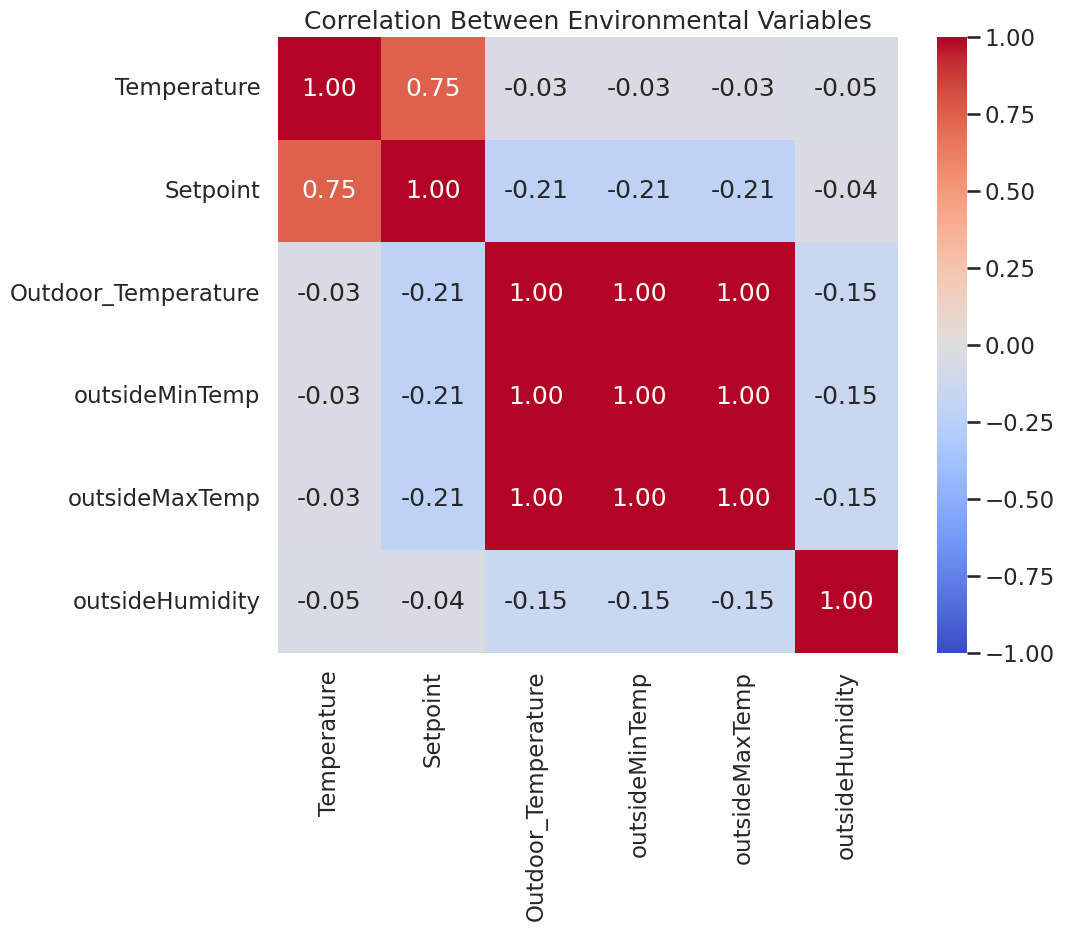

7103

In [11]:
# Generate a correlation matrix to identify simple linear relationships between the indoor climate, 
# outdoor weather, and system setpoints
#
corr_cols = ["Temperature", "Setpoint", "Outdoor_Temperature", "outsideHumidity", "outsideMinTemp", "outsideMaxTemp"]
corr_df = pd.concat([chunk.dropna() for chunk in pd.read_csv(EDA_FILE, usecols=lambda c: c in corr_cols, chunksize=100000)])

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, center=0)
plt.title("Correlation Between Environmental Variables")
plt.show()

del corr_df
gc.collect()

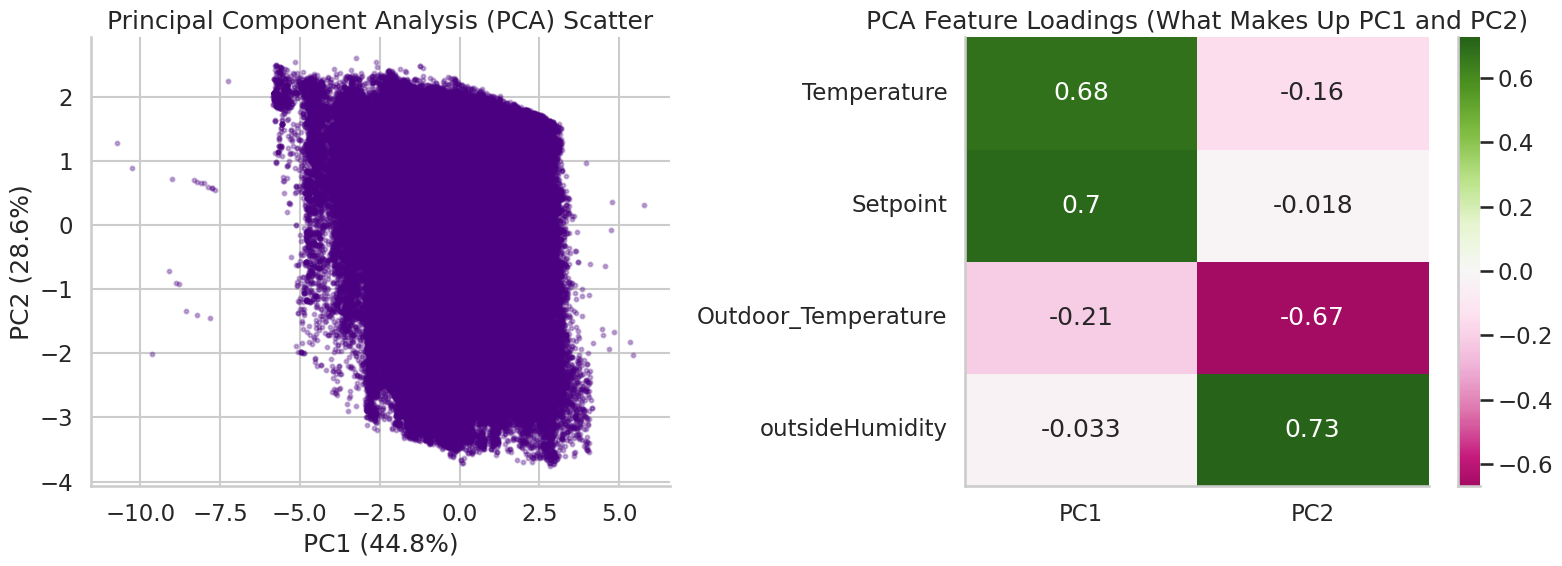

39

In [12]:
# Perform Principal Component Analysis to reduce the environmental variables into two main dimensions
# and plot a loadings heatmap to reveal exactly which original variables make up these new components
#
pca_cols = ["Temperature", "Setpoint", "Outdoor_Temperature", "outsideHumidity"]
pca_data = pd.concat([chunk.dropna().sample(frac=0.1, random_state=42) for chunk in pd.read_csv(EDA_FILE, usecols=lambda c: c in pca_cols, chunksize=100000)])

X = StandardScaler().fit_transform(pca_data.values)
pca = PCA(n_components=2)
comps = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(comps[:, 0], comps[:, 1], s=8, alpha=0.3, color="indigo")
axes[0].set_title("Principal Component Analysis (PCA) Scatter")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

loadings = pd.DataFrame(pca.components_.T, index=pca_data.columns, columns=["PC1", "PC2"])
sns.heatmap(loadings, annot=True, cmap="PiYG", center=0, ax=axes[1])
axes[1].set_title("PCA Feature Loadings (What Makes Up PC1 and PC2)")

sns.despine()
plt.tight_layout()
plt.show()

del pca_data, X, comps, loadings
gc.collect()

In [13]:
display(pd.DataFrame({"Generated ML Files": len(glob.glob(os.path.join(PROCESSED_FOLDER, "*.csv")))}, index=["Status"]))

,Generated ML Files
Status,100
